#  Proyecto de NLP

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv"
df = pd.read_csv(url)

 
print(df.head())
print(df['is_spam'].value_counts())  

                                                 url  is_spam
0  https://briefingday.us8.list-manage.com/unsubs...     True
1                             https://www.hvper.com/     True
2                 https://briefingday.com/m/v4n3i4f3     True
3   https://briefingday.com/n/20200618/m#commentform    False
4                        https://briefingday.com/fan     True
is_spam
False    2303
True      696
Name: count, dtype: int64


In [3]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/vscode/nltk_data...


True

In [5]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

 
url = "https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv"
df = pd.read_csv(url)

 
def clean_url(url):
     
    url = re.sub(r'https?://|www\.', '', url)
     
    url = re.sub(r'[^a-zA-Z]', ' ', url)
     
    words = url.lower().split()
    
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned)

 
df['cleaned_url'] = df['url'].apply(clean_url)

 
print(df[['url', 'cleaned_url']].head())

                                                 url  \
0  https://briefingday.us8.list-manage.com/unsubs...   
1                             https://www.hvper.com/   
2                 https://briefingday.com/m/v4n3i4f3   
3   https://briefingday.com/n/20200618/m#commentform   
4                        https://briefingday.com/fan   

                                 cleaned_url  
0  briefingday u list manage com unsubscribe  
1                                  hvper com  
2                      briefingday com v n f  
3              briefingday com n commentform  
4                        briefingday com fan  


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

 
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned_url'])
y = df['is_spam']

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")  

X_train shape: (2399, 5440)


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

 
svm_model = SVC(kernel='linear', random_state=42) 
svm_model.fit(X_train, y_train)

 
y_pred = svm_model.predict(X_test)

print("--- RESULTADOS MODELO BASE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

--- RESULTADOS MODELO BASE ---
Accuracy: 0.9533

Matriz de Confusión:
[[446   9]
 [ 19 126]]

Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.96      0.98      0.97       455
        True       0.93      0.87      0.90       145

    accuracy                           0.95       600
   macro avg       0.95      0.92      0.93       600
weighted avg       0.95      0.95      0.95       600



In [8]:
from sklearn.model_selection import GridSearchCV

 
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']  
}

 
grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, verbose=1, scoring='f1')
grid.fit(X_train, y_train)

 
print(f"Mejores parámetros encontrados: {grid.best_params_}")

 
best_model = grid.best_estimator_
y_pred_opt = best_model.predict(X_test)

print("\n--- RESULTADOS MODELO OPTIMIZADO ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_opt))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros encontrados: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

--- RESULTADOS MODELO OPTIMIZADO ---
Accuracy: 0.9650

Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.97      0.98      0.98       455
        True       0.94      0.91      0.93       145

    accuracy                           0.96       600
   macro avg       0.96      0.95      0.95       600
weighted avg       0.96      0.96      0.96       600



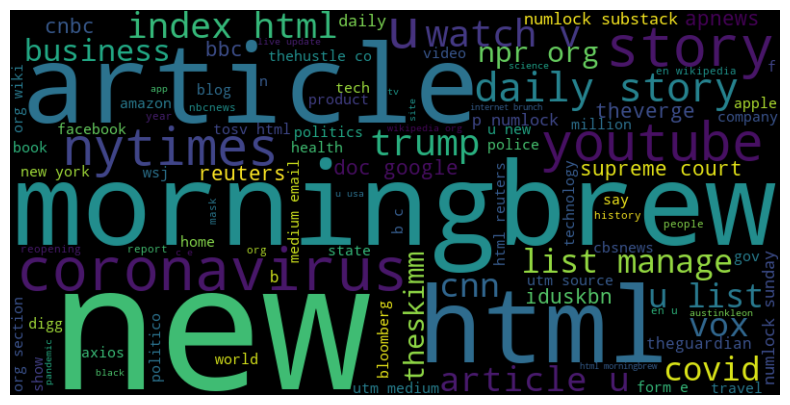

In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

 
all_words = " ".join(df['cleaned_url'])

 
wordcloud = WordCloud(width=800, height=400, 
                      background_color='black', 
                      colormap='viridis',
                      max_words=100).generate(all_words)

 
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  
plt.show()

In [11]:
import os
if not os.path.exists('models'):
    os.makedirs('models')

 
from pickle import dump
dump(best_model, open("models/svm_classifier_optimizado.sav", "wb"))
print("Proyecto completado /models")

Proyecto completado /models
